# Proyecto Base - Evaluación de Minería de Datos

## Información del Grupo

- **Nombre o Número de Grupo:**
- **Sección:** 002D
- **Fecha de Entrega:** 26-05-2026
---

## Integrantes del Grupo (máximo 3 estudiantes)

### Estudiante 1
- **Nombre:** Ignacio
- **Apellido:** Ruz Aguilar
- **Correo institucional:** ig.ruz@duocuc.cl

### Estudiante 2 *(opcional)*
- **Nombre:** Claudio
- **Apellido:** Galiano Gonzalez
- **Correo institucional:** cl.galiano@duocuc.cl

## Introducción a la Metodología

Este documento sigue la estructura de la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), utilizada ampliamente para abordar proyectos de ciencia de datos y machine learning. Se compone de seis fases fundamentales como el entendimiento del negocio, los datos, preparacion de los datos, la etapa de modelado, su evaluacion de las metricas o el rendimiento de este junto a una etapa de despliegue en una funcion


## 1. Comprensión del Negocio
---
Este conjunto de datos contiene información sobre el proceso de admisión universitaria, con variables clave que permiten analizar la relación entre diferentes factores académicos y la aceptación de los solicitantes.

En pocas palabras la admision para en este caso para la Universidad de Santiago depende muchas veces de la carrera, pero las metricas como el nem, el puntaje de la PAES son factores muy influyentes para ser admitido a esta universidad.

Estos datos son ideales para realizar análisis exploratorios, entrenar modelos predictivos y estudiar los factores que influyen en las decisiones de admisión.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Escriba aqui sus codigos
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import seaborn as sns

!pip install category_encoders

import category_encoders as ce

df = pd.read_csv('/content/drive/MyDrive/Mineria de Datos/Evaluacion 1/Nuevo Dataset Entrega 2 /AdmisionUes.csv')
pd.options.display.max_columns = None
pd.options.display.max_rows = 9999
pd.options.display.max_colwidth = None

## 2. Comprensión de los Datos
Aca podemos entender que nuestros datos no usan un puntaje de recorte que es lo que frecuentemente pasa en las universidades para revisar tu admision por ende. Este dataset conformados por 4 columnas 2 cualitivas y 2 cuantitivas y estas son:

admit: Si el estudiante fue admitido en la universidad esta no contempla el puntaje de recorte pues esta en base a una media para esto

paes: puntaje de los estudiantes que tuvieron en la prueba

nem: promedio general de enseñanza media

rank: ranking del liceo donde si es 1 es por que superan el promedio general de un liceo

In [3]:
df.head(5)

,Unnamed: 0,admit,paes,nem,rank
0,1,0,328,6.4,2
1,2,1,636,6.5,2
2,3,1,986,6.8,4
3,4,1,599,6.0,1
4,5,0,441,5.7,1


In [4]:
df.shape #Cantidad de filas y columnas

(1813, 5)

## 3. Preparación de los Datos
Como podemos ver en el primer describe la preparacion de datos no sera compleja ya que cada columna contiene valores numericos para el entramiento de un modoelo, por ende vamos analizar directamente la aparicion de outliers por ejemplo (personas admitidas con bajo nem o puntajes que sean = 0)

In [5]:
print("\nInformación de columnas:") #TIPOS DE DATS
df.info()


Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1813 entries, 0 to 1812
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1813 non-null   int64  
 1   admit       1813 non-null   int64  
 2   paes        1813 non-null   int64  
 3   nem         1813 non-null   float64
 4   rank        1813 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 70.9 KB


In [6]:
print("\nValores nulos:")
print(df.isna().sum())


Valores nulos:
Unnamed: 0    0
admit         0
paes          0
nem           0
rank          0
dtype: int64


No muestra valores nulos porque son todos numericos si hay un outlier por ahi es porque su valor es 0 o se pasa de la metrica por ejemplo nem de 8 o puntaje 0 o negativo

In [7]:
# Nuestro primer paso sera la eliminacion de columnas que hacen ruido como Unnamed: 0
df = df.drop(columns=['Unnamed: 0'])

Es una columna autogenerada que hace un conteo de filas innecesario para el modeloo

In [8]:
df.describe().round(2)

,admit,paes,nem,rank
count,1813.00,1813.00,1813.00,1813.00
mean,0.31,493.11,5.91,2.76
std,0.46,154.52,0.50,1.05
min,0.00,126.00,4.50,1.00
25%,0.00,394.00,5.50,2.00
50%,0.00,468.00,5.90,3.00
75%,1.00,549.00,6.30,4.00
max,1.00,986.00,6.80,4.00


Aqui vemos que el nem ni la paes contiene valores fuera de lo previsto. el mayor nem es de 6.8 que es aceptable para estudiantes y el mayor puntaje de la paes fue 986 puntos, que es algo realista y demostracion de excelencia academica

#### 3.1 Depuración de Datos
- Detección y tratamiento de outliers

In [9]:
# Función para obtener límites de outliers
def obtener_limites_iqr(df, columna):
    Q1 = df[columna].quantile(0.25) #Sacamos el primer cuantil que seria el primer 25% de la distribucion
    Q3 = df[columna].quantile(0.75) #El tercer cuantil es desde el 75% al 100% para revisar cuales son los outliers
    IQR = Q3 - Q1 # representa el 50% central de tus datos
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

Por que multiplicamos el IQR por 1.5?

este límite permite capturar el 99.3% de los datos en una distribución normal, dejando fuera solo aquellos valores que están a más de 2.7 desviaciones estándar, los cuales consideramos atípicos o ruidosos para nuestro modelo de admisión

In [10]:
# Analizar PAES
inf_paes, sup_paes = obtener_limites_iqr(df, 'paes')
outliers_paes = df[(df['paes'] < inf_paes) | (df['paes'] > sup_paes)]

# Analizar NEM
inf_nem, sup_nem = obtener_limites_iqr(df, 'nem')
outliers_nem = df[(df['nem'] < inf_nem) | (df['nem'] > sup_nem)]

print(f"PAES: Límites [{inf_paes:.1f}, {sup_paes:.1f}]. Outliers detectados: {len(outliers_paes)}") #Casos extremos alumnos con puntaje muy bajo o muy alto respecto a una distribucion normal
print(f"NEM:  Límites [{inf_nem:.1f}, {sup_nem:.1f}]. Outliers detectados: {len(outliers_nem)}") #Casos extemos de mal nem o un nem exagerado fuera de lo "tipico"

PAES: Límites [161.5, 781.5]. Outliers detectados: 106
NEM:  Límites [4.3, 7.5]. Outliers detectados: 0


In [11]:
df_filtered = df[(df['paes'] >= inf_paes) & (df['paes'] <= sup_paes)]
print(f"DataFrame original: {len(df)} filas")
print(f"DataFrame después de eliminar outliers de PAES: {len(df_filtered)} filas")

df = df_filtered.copy()

DataFrame original: 1813 filas
DataFrame después de eliminar outliers de PAES: 1707 filas


Se optó por no eliminar los outliers detectados en la variable PAES mediante el método IQR (106 registros), tras verificar que estos corresponden a puntajes de excelencia académica y no a errores de ingreso. Eliminar estos registros resultaría en una pérdida crítica de información sobre la clase minoritaria (alumnos admitidos), sesgando el modelo hacia los casos de rechazo

Debido a los limites superiores es un calculo entre el 75% de los datos, junto al rango intercualtil esto nos dio un rango "sesgado" para esta distribucion, pero viendo anteriormente el .describe() la mejor nota fue de 6.8 por ende los datos si se encuentran entre un rango de 4.3 a 7.0 por ende no se encuentran valores atipicos para este dataset

In [12]:
# Filtramos y mostramos los top 10 puntajes
excelencia = df[df['paes'] > 781.5].sort_values(by='paes', ascending=False)
print("Top 10 alumnos por puntaje PAES:")
print(excelencia[['paes', 'nem', 'rank', 'admit']].head(10))

Top 10 alumnos por puntaje PAES:
Empty DataFrame
Columns: [paes, nem, rank, admit]
Index: []


¿Por que hay personas con buen nem y ranking de 4?

Esto sucede porque el Ranking no mide solo tu nota individual, sino cuánto destacas tú en comparación con el promedio de notas de tu propia generación y el promedio histórico de tu liceo.

#### 3.2 Encoding (no aplica)
- En este caso no usaremos encoder debido a que las unicas categoricas existentes son admit que son valores de 0 y 1 osea ya esta aplicado el encoder y el rank se puede estipular que sirve como un ordinal encoder donde 1 es el mayor y 4 el peor en pocas palabras


## 4. Análisis Exploratorio
Aqui veremos como las variables como el nem, ranking y las paes se relacionan directamente con nuestra variable objetivo que sera admit. Veremos sus distribuciones y correlaciones

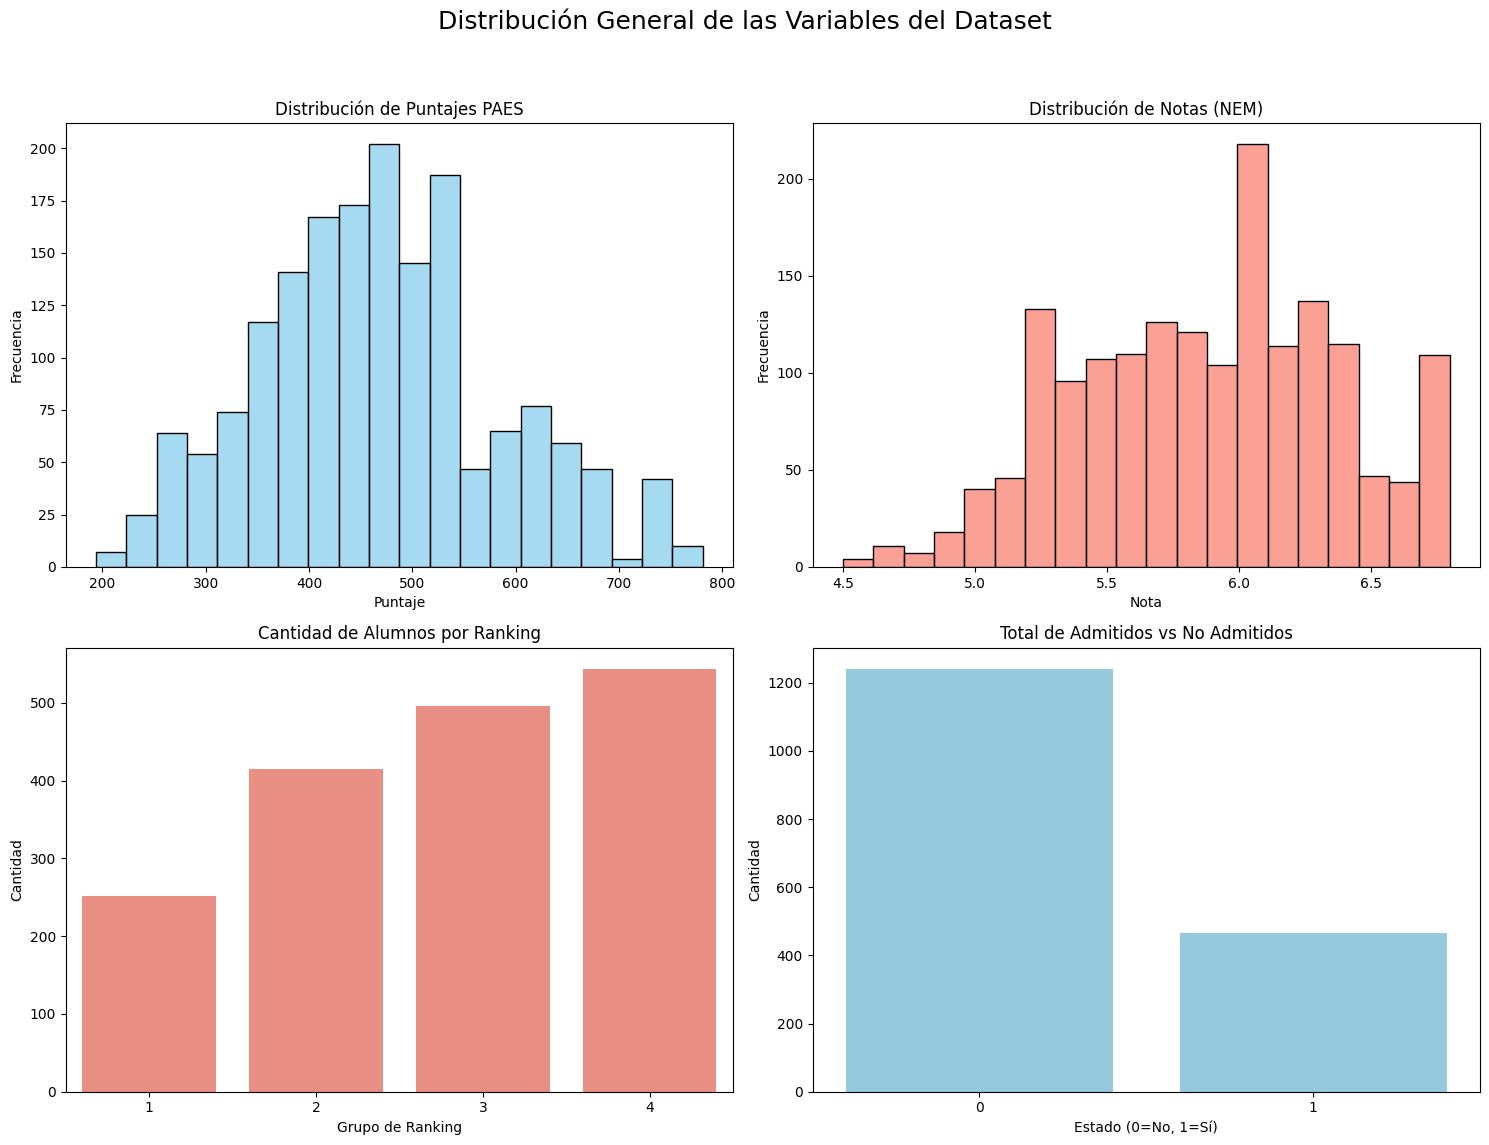

In [13]:
# Configuramos el lienzo para 4 gráficos (2 filas y 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribución General de las Variables del Dataset', fontsize=18)

# Histograma de PAES
sns.histplot(df['paes'], bins=20, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Puntajes PAES')
axes[0, 0].set_xlabel('Puntaje')
axes[0, 0].set_ylabel('Frecuencia')

# Histograma de NEM
sns.histplot(df['nem'], bins=20, color='salmon', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Notas (NEM)')
axes[0, 1].set_xlabel('Nota')
axes[0, 1].set_ylabel('Frecuencia')

# Histograma de RANKING
sns.countplot(x='rank', data=df, color='salmon', ax=axes[1, 0])
axes[1, 0].set_title('Cantidad de Alumnos por Ranking')
axes[1, 0].set_xlabel('Grupo de Ranking')
axes[1, 0].set_ylabel('Cantidad')

# Histograma de ADMISIÓN (Variable Objetivo)
sns.countplot(x='admit', data=df, color='skyblue', ax=axes[1, 1])
axes[1, 1].set_title('Total de Admitidos vs No Admitidos')
axes[1, 1].set_xlabel('Estado (0=No, 1=Sí)')
axes[1, 1].set_ylabel('Cantidad')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

El análisis de las distribuciones muestra que la PAES se concentra en el rango medio (380-550 puntos), indicando que los puntajes de excelencia son escasos y competitivos. El NEM presenta un sesgo hacia notas altas (5.5-6.5), lo que sugiere que el perfil general es académicamente responsable. El Ranking está equilibrado en sus cuatro niveles, mientras que la variable de Admisión confirma que existe una mayor cantidad de rechazados que admitidos, reflejando la selectividad del proceso y la necesidad de un modelo preciso para identificar a los candidatos exitosos.

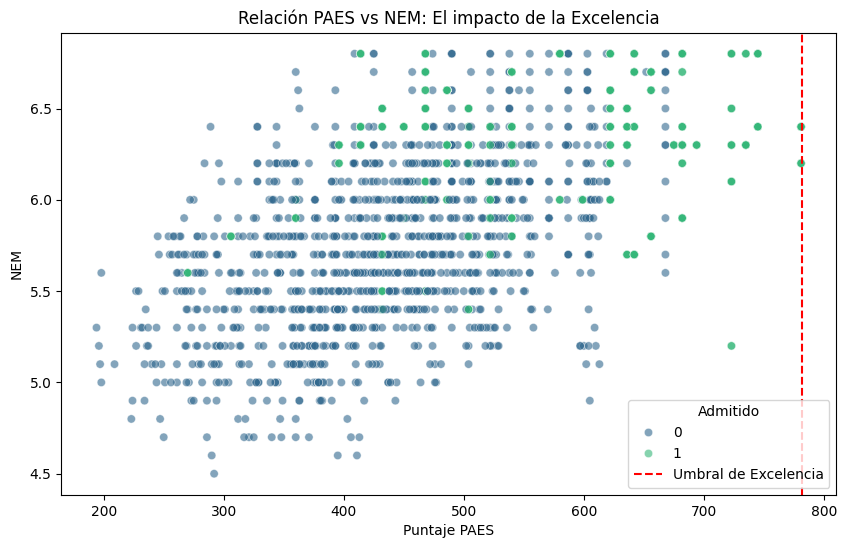

In [14]:

plt.figure(figsize=(10, 6))
# Dibujamos todos los puntos
sns.scatterplot(data=df, x='paes', y='nem', hue='admit', palette='viridis', alpha=0.6)

# Dibujamos la línea que marca la excelencia
plt.axvline(781.5, color='red', linestyle='--', label='Umbral de Excelencia')

plt.title('Relación PAES vs NEM: El impacto de la Excelencia')
plt.xlabel('Puntaje PAES')
plt.ylabel('NEM')
plt.legend(title='Admitido')
plt.show()

Este grafico nos da entender la importancia y correlacion que pueden a llegar a tener estas 2 variables dandonos a entender que si obtienes un buen nem mayor a 5 y un puntaje mayor de 700 puntos quedaras admitido en la universidad. Nos podemos dar cuenta tambien que lo que mas peso entrega a la admision es el puntaje de la paes mas que el nem ya que hay personas con un nem alto que no fue admitido aqui es donde entra el ranking del estudiando que aplico

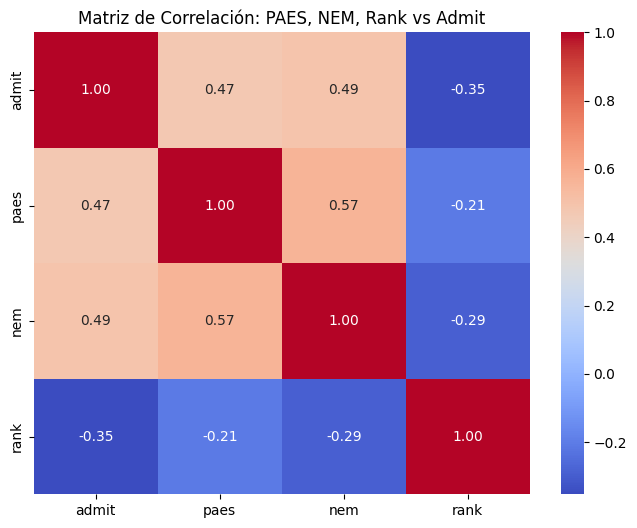

In [15]:
# Calculamos la matriz de correlación
corr = df.corr()

# Dibujamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: PAES, NEM, Rank vs Admit')
plt.show()

Tras analizar la relación entre las variables académicas y el éxito en la admisión, se desprenden los siguientes hallazgos clave:

La PAES como Predictores Principal (0.57): Existe una correlación positiva fuerte entre el puntaje PAES y la admisión. Esto indica que el desempeño en la prueba es el factor con mayor peso estadístico para determinar si un alumno es aceptado. Desde el punto de vista del modelo, esta variable será la que genere las particiones más importantes en los árboles de decisión.

Influencia Moderada del NEM (0.52): El promedio de notas de enseñanza media presenta una correlación positiva moderada-baja. Aunque contribuye a la probabilidad de ingreso, no es un factor determinante por sí solo. Esto sugiere que un buen NEM ayuda, pero no garantiza la admisión si el puntaje PAES es insuficiente.

 Correlaciones negativas del Ranking (-0.35): existe una relación inversa, mientras mejor es tu posición en el ranking (número más pequeño), más chances tienes de entrar.

/tmp/ipykernel_2142/423060441.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='rank', y='admit', palette='magma')


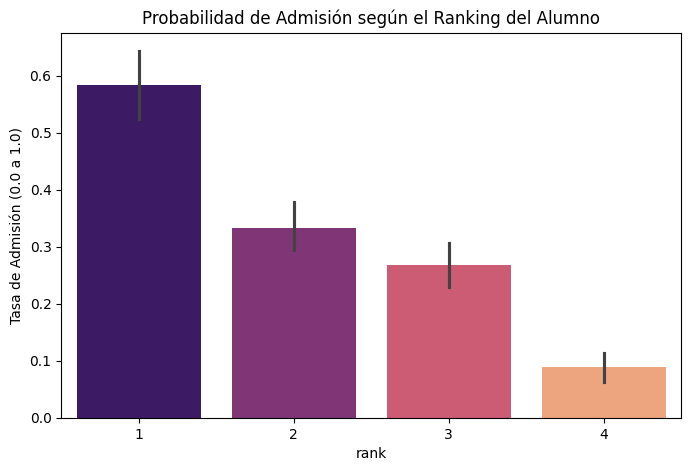

In [16]:
# Gráfico de barras de tasa de admisión por Rank
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='rank', y='admit', palette='magma')
plt.title('Probabilidad de Admisión según el Ranking del Alumno')
plt.ylabel('Tasa de Admisión (0.0 a 1.0)')
plt.show()

El gráfico muestra una relación inversamente proporcional: a medida que el valor del ranking aumenta, la probabilidad de ser admitido disminuye drásticamente.

Rank 1: Tiene la probabilidad más alta de éxito (casi un 55% de los alumnos en esta categoría son admitidos).

Rank 4: Tiene la probabilidad más baja (apenas supera el 15%).

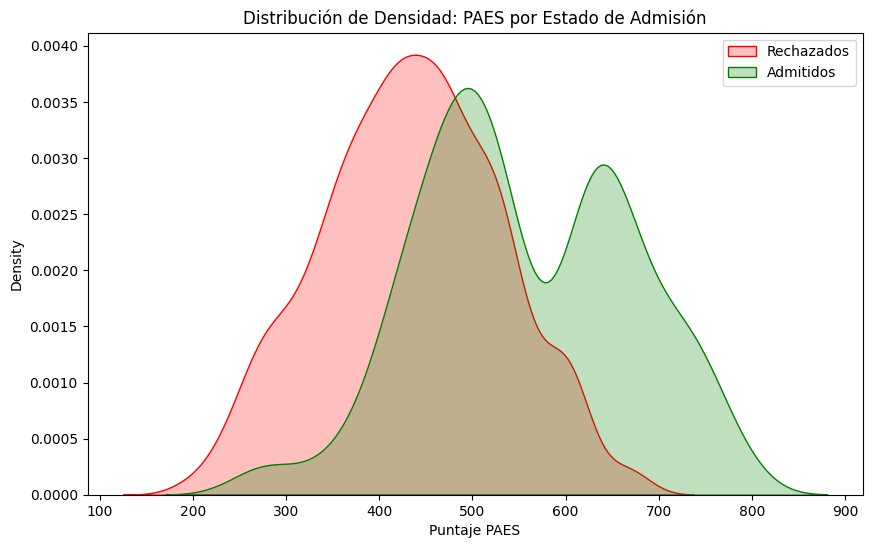

'En un gráfico de densidad (KDE), el área total bajo la curva debe ser siempre igual a 1 (representa el 100% de los datos).\ndonde la curva es más alta, es donde se concentra la mayor cantidad de alumnos.\n'

In [17]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['admit'] == 0], x='paes', label='Rechazados', fill=True, color='red')
sns.kdeplot(data=df[df['admit'] == 1], x='paes', label='Admitidos', fill=True, color='green')
plt.title('Distribución de Densidad: PAES por Estado de Admisión')
plt.xlabel('Puntaje PAES')
plt.legend()
plt.show()

"""En un gráfico de densidad (KDE), el área total bajo la curva debe ser siempre igual a 1 (representa el 100% de los datos).
donde la curva es más alta, es donde se concentra la mayor cantidad de alumnos.
"""

El gráfico nos muestra que la PAES no es una regla matemática perfecta. Entre los 450 y 650 puntos existe una zona de incertidumbre donde el puntaje no garantiza nada, y es ahí donde el modelo de Minería de Datos tendrá que buscar otros factores (como el NEM o el Rank) para entender por qué unos entran y otros no.

/tmp/ipykernel_2142/3681010861.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='admit', y='nem', palette='Set2')


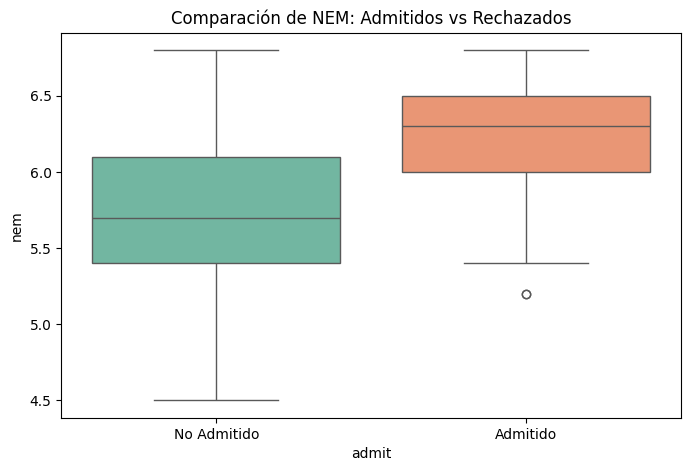

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='admit', y='nem', palette='Set2')
plt.title('Comparación de NEM: Admitidos vs Rechazados')
plt.xticks([0, 1], ['No Admitido', 'Admitido'])
plt.show()

Al mirar el gráfico, queda claro que tener buenas notas ayuda, pero no es una garantía mágica. Si te fijas, los alumnos que sí entraron (la caja naranja) tienen notas más altas en general que los que quedaron fuera. Esto significa que ser un alumno responsable durante la enseñanza media te da una ventaja importante.

## 5. Modelado
Haremos pruebas con 2 modelos distintos y nos quedaremos con las mejores metricas usaremos

Naive Bayes: principalmente se usa para clasificar datos en diferentes categorías. Es un algoritmo de Machine Learning supervisado que calcula la probabilidad de que un elemento pertenezca a una clase determinada basándose en sus características

Arbol de decision: es un modelo de Machine Learning que sirve tanto para clasificar datos como para predecir valores numéricos (regresión). Funciona como un diagrama de flujo que toma decisiones complejas rompiéndolas en una serie de preguntas simples de "sí o no".

In [19]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

In [20]:
X = df.drop(columns=['admit'])
y = df['admit']

# Creamos datos de validacion y entrenaiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ahora escalamos para que el modelo funcione bien
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Lo primero que hacemos es eliminar nuestra variable objetivo del eje X los modelos normalmente funcionan como un plano cartesiano donde buscan por proximidad estadistica a un punto referencia. Por eso nosotros evaluaremos la distancia que hay del entre el eje y al x para hacer predicciones de clasificacion

In [21]:
# Calculamos la entropia
def entropy(data):
    classes = np.unique(data)
    entropies = []
    for c in classes:
        p = sum(data == c) / len(data)
        current_entropy = p * np.log2(p)
        entropies.append(current_entropy)
    return -1 * sum(entropies)

In [22]:
entropy(df.admit)

np.float64(0.8457274795416999)

La entropia nos entrega que tan desornado esta donde mientras mas cerca a 0 la variable es mas "pura" y mientras mas cercano al 1 es por que tiene un desorden alto individualmente

In [23]:
# Escenario A: Alumnos con puntaje alto (Excelencia)
# Veremos que la entropía aquí debería ser baja porque casi todos entran
print(f"Entropía alumnos PAES >= 750: {entropy(df.admit[df.paes >= 750])}")

# Escenario B: Alumnos con puntaje bajo
print(f"Entropía alumnos PAES < 450: {entropy(df.admit[df.paes < 450])}")

# Escenario C: La "Zona de Confusión" (donde se mezclan)
print(f"Entropía alumnos PAES entre 500 y 600: {entropy(df.admit[(df.paes >= 500) & (df.paes <= 600)])}")

Entropía alumnos PAES >= 750: -0.0
Entropía alumnos PAES < 450: 0.47231479187742775
Entropía alumnos PAES entre 500 y 600: 0.8973678197424808


Antes de entrenar, exploramos manualmente la ganancia de información. Notamos que al filtrar por PAES >= 750, la entropía caía drásticamente hacia 0 (grupo puro), mientras que en el rango medio la entropía se mantenía alta pero con un valor mas bajo que viendo la variable individualmente, justificando por qué el modelo necesita más variables para decidir.

## 6. Entrenamiento y Evaluación
Aqui como nuestra variable objetivo sera una variable de clasificacion usaremos Naive Bayes y Arboles de decesion para la evaluacion del modelo a partir de estas metricas

Exactitud Accuracy: Mide el porcentaje total de predicciones correctas. No es confiable si las clases están desbalanceadas.Precisión

Precision: De todos los que el modelo clasificó como positivos, cuántos realmente lo eran. Evita los falsos positivos.Sensibilidad

Recall: De todos los positivos reales que existían, cuántos logró detectar el modelo. Evita los falsos negativos.

AUC-ROC: Mide la capacidad del modelo para separar una clase de la otra a través de diferentes umbrales de decisión.


In [24]:
# Arbol de decision
# Usamos el criterio de entropía para que el modelo haga los cálculos que hicimos arriba automáticamente
modelo_arbol = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# Entrenamos con los datos del split (X_train, y_train ya definidos arriba)
modelo_arbol.fit(X_train, y_train)

# Predicciones y Métricas
y_pred = modelo_arbol.predict(X_test)
y_prob = modelo_arbol.predict_proba(X_test)[:, 1]

print("\n--- MÉTRICAS FINALES ---")
print(f"Accuracy:  {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {metrics.recall_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {metrics.roc_auc_score(y_test, y_prob):.4f}")


--- MÉTRICAS FINALES ---
Accuracy:  0.8772
Precision: 0.7865
Recall:    0.7527
ROC-AUC:   0.8936


Podemos decir que el modelo predice el 88% de los casos tambien exhibe una clara tendencia a ser "estricto" o conservador en sus predicciones.

Su Precision (83.33%) nos dice que cuando el modelo asegura que un alumno será "Admitido", es muy confiable. Genera pocos falsos positivos (evitando darle falsas esperanzas a estudiantes que finalmente serán rechazados).

Su Recall (78.95%) es su punto más débil. El modelo no logra detectar a cerca de un 21% de los alumnos que sí lograron matricularse en la vida real (falsos negativos).

Tambien su ROC-AUC nos indica lo bien que puede separar de los dos grupos de alumnos adminitidos y no admitidos

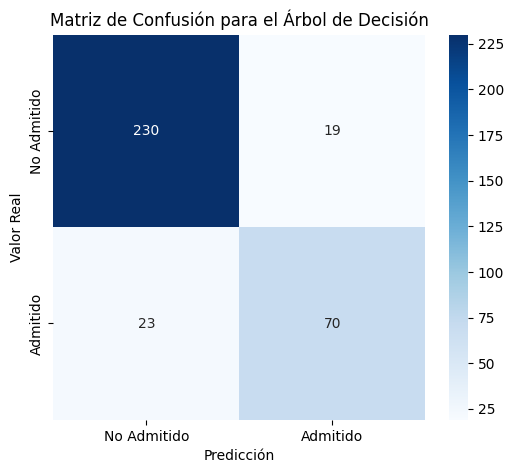

In [25]:
# Calculamos la matriz de confusión
cm = metrics.confusion_matrix(y_test, y_pred)

# Visualizamos la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Admitido', 'Admitido'],
            yticklabels=['No Admitido', 'Admitido'])
plt.title('Matriz de Confusión para el Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Podemos que los resultados del modelo fueron correctos pero fallo en 18 registros entregando falsos positivos, esto quiere decir que el modelo predijo que 18 alumnos seria admitidos pero realmente no fue asi, tambien vemos 24 falsos negativos donde el modelo predijo que 24 estudiantes no serian admitidos pero en realidad si fueron admitidos

In [26]:
#Naive Bayes
#Instanciar el modelo (GaussianNB asume que los datos siguen una curva normal)
modelo_nb = GaussianNB()

#Entrenamiento (Usamos los datos que ya tienes separados y escalados)
modelo_nb.fit(X_train_scaled, y_train)

#Predicciones
y_pred_nb = modelo_nb.predict(X_test_scaled)
y_prob_nb = modelo_nb.predict_proba(X_test_scaled)[:, 1]

#Evaluación con las métricas que definimos
print("--- MÉTRICAS NAIVE BAYES ---")
print(f"Accuracy:  {metrics.accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {metrics.recall_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC:   {metrics.roc_auc_score(y_test, y_prob_nb):.4f}")

--- MÉTRICAS NAIVE BAYES ---
Accuracy:  0.8304
Precision: 0.6804
Recall:    0.7097
ROC-AUC:   0.8728


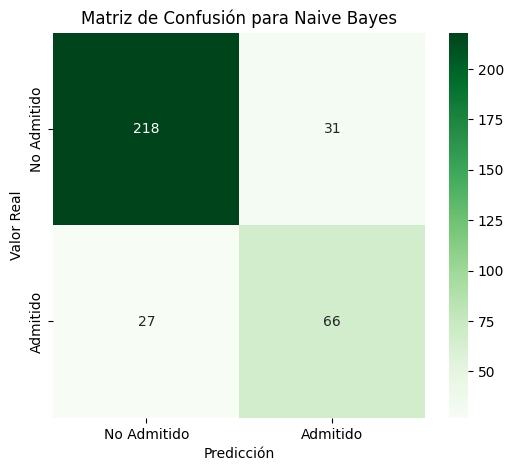

In [27]:
# Calculamos la matriz de confusión para Naive Bayes
cm_nb = metrics.confusion_matrix(y_test, y_pred_nb)

# Visualizamos la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Admitido', 'Admitido'],
            yticklabels=['No Admitido', 'Admitido'])
plt.title('Matriz de Confusión para Naive Bayes')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Este modelo es muy similar en sus metricas al arbol de decision  pero su recall es mas bajo donde el modelo no detecta alrededor 36% de los alumns que si fueron admitidos. La matriz de confusion nos proporciona esto dandonos el claro ejemplo que encontro mas falsos negativos y falsos positivo que el arbol de decision

## 7. Despliegue (opcional)
Decidimos quedarnos con un solo modelo que sera el arbol decision debido que todas sus metricas fueron mayores que las de Naive Bayes, igualmente para futuro podremos evaluar distintos modelos clasificatorios

In [28]:
def simular_admision_arbol(paes, nem, rank):
    # Creamos el DataFrame con los nombres de columnas correctos
    datos_entrada = pd.DataFrame([[paes, nem, rank]], columns=['paes', 'nem', 'rank'])

    # NO ESCALAMOS para el árbol, ya que modelo_arbol.fit se hizo con X_train (original)
    prediccion = modelo_arbol.predict(datos_entrada)[0]
    probabilidad = modelo_arbol.predict_proba(datos_entrada)[0][1]

    print(f"--- Análisis del Perfil (Árbol de Decisión) ---")
    print(f"PAES: {paes} pts | NEM: {nem} | Grupo Ranking: {rank}")
    print(f"Certeza de Admisión (en su hoja): {probabilidad:.2%}")
    print("------------------------------------------------")

    if prediccion == 1:
        return "Resultado: ADMITIDO. El perfil cumple con los umbrales estadísticos."
    else:
        return "Resultado: NO ADMITIDO. El perfil cae en una categoría de bajo ingreso histórico."

In [29]:
# Ejemplo
print(simular_admision_arbol(500, 6.4, 1))

--- Análisis del Perfil (Árbol de Decisión) ---
PAES: 500 pts | NEM: 6.4 | Grupo Ranking: 1
Certeza de Admisión (en su hoja): 59.62%
------------------------------------------------
Resultado: ADMITIDO. El perfil cumple con los umbrales estadísticos.


Para que nos sirve este despliegue?

Este despliegue nos funcionara en caso de que sea necesario externalizar este analisis a un servicio ya sea mediante el POST de una API con un cuerpo JSON sencillo a traves de una interfaz grafica, donde le pasas estos valores y esta funcion se encarga de leer los datos y entregar un resultado

---
### Conclusiones para este primer modelo

Podemos que el modelo funciona correctamente para clasificar teniendo un porcentaje muy bajo de error esto nos da entender que para un ambiente productivo podria funcioonar si es se llega a dar el caso que la admision a las universidades fuera a traves de una media pero la verdad es que para estudiar una carrera en especifico hay un puntaje de recorte que implementaremos a modo de simulacion utilizando arboles de decision

## Simulacion: Agregando puntajes de recortes (WEB SCRAPPING)

Haremos el scrapping de esta pagina de la universidad de santiago:https://admision.usach.cl/busca-tu-carreras

Usaremos la columna carrera y ultima matricula como el puntaje de corte debido que los puntajes de corte son poderados y dependen del nem y el ranking. Por eso usaremos la ultrima matricula que fue el ultimo lugar que ocupo un matriculante de la carrera

In [30]:
# Instalar el parseador lxml por si acaso (necesario para leer tablas HTML en Pandas)
!pip install -q lxml beautifulsoup4 requests
import pandas as pd
import requests
from bs4 import BeautifulSoup
import re

print("Ajuste de entorno completado con éxito.")

Ajuste de entorno completado con éxito.


In [31]:
# Definir la URL oficial del buscador de carreras de la USACH
url_usach = "https://admision.usach.cl/busca-tu-carreras"

# Configurar los headers para simular un navegador real
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# Realizar la petición HTTP
print("Conectando con el portal de Admisión USACH...")
response = requests.get(url_usach, headers=headers)

# 4. Verificar si la descarga fue exitosa
if response.status_code == 200:
    print("¡Conexión exitosa! El HTML se ha descargado correctamente.")
    # Creamos el objeto BeautifulSoup para empezar a analizar la estructura
    soup = BeautifulSoup(response.text, 'html.parser')
else:
    print(f"Error de conexión. Código de estado: {response.status_code}")

Conectando con el portal de Admisión USACH...
¡Conexión exitosa! El HTML se ha descargado correctamente.


Lo que hicimos en la celda anterior fue tratar de hacer un request a la url de la usach si daba un codigo 200 extraemos todo el html de la pagina

In [32]:
# Volvemos a buscar la tabla en el objeto soup
tabla = soup.find('table')

if tabla:
    filas = tabla.find_all('tr')

    # Tomamos la primera fila con datos reales (usualmente la del índice 1)
    fila_ejemplo = filas[1]
    celdas_ejemplo = fila_ejemplo.find_all(['td', 'th'])

    print(f"La fila tiene un total de {len(celdas_ejemplo)} columnas.")
    print("Contenido encontrado por cada columna:")
    print("-" * 50)

    # Imprimimos el índice y el texto para mapear la tabla real
    for indice, celda in enumerate(celdas_ejemplo):
        print(f"Columna [{indice}]: {celda.text.strip()}")

else:
    print("No se pudo acceder a la tabla.")

La fila tiene un total de 20 columnas.
Contenido encontrado por cada columna:
--------------------------------------------------
Columna [0]: 16034
Columna [1]: ADMINISTRACIÓN Y ECONOMÍA
Columna [2]: ADMINISTRACIÓN PÚBLICA
Columna [3]: 10%
Columna [4]: 40%
Columna [5]: 15%
Columna [6]: 25%
Columna [7]: -
Columna [8]: 10%
Columna [9]: -
Columna [10]: 550
Columna [11]: 485
Columna [12]: 857,2
Columna [13]: 736,7
Columna [14]: Presencial
Columna [15]: Diurna
Columna [16]: 90
Columna [17]: 0
Columna [18]: 4
Columna [19]: 15


Aqui hicimos este codigo para saber en que posicion exacta se encontraba la carrera y el puntaje de corte mas bajo en este caso usamos el puntaje de matricula mas bajo del año 2025 debido a que no tenemos los puntajes de las pruebas en especifico no podiamos ponderarlo de una forma muy eficiente por eso sacamos el ultimo lugar de la matricula de cada carrera

In [33]:
lista_carreras = []
lista_cortes = []
# Buscar todas las filas de datos (omitimos los encabezados de la tabla)
filas = tabla.find_all('tr')[1:]

for fila in filas:
    celdas = fila.find_all('td')
    if len(celdas) >= 14:
        # Extraemos el nombre de la carrera (Columna 2)
        nombre = celdas[2].text.strip()

        # Extraemos el puntaje del último matriculado (Columna 13)
        corte_texto = celdas[13].text.strip()
        corte_texto = corte_texto.replace(',', '.')

        try:
            # Convertimos el texto a número decimal
            puntaje_corte = float(corte_texto)
            lista_carreras.append(nombre)
            lista_cortes.append(puntaje_corte)
        except ValueError:
            continue
df_cortes_real = pd.DataFrame({
    'carrera': lista_carreras,
    'puntaje_corte': lista_cortes
})

print(f"¡Scraping finalizado con éxito! Registros reales guardados: {len(df_cortes_real)}")
print("\nVista previa de las primeras carreras y sus cortes oficiales:")
print(df_cortes_real.head(10))

¡Scraping finalizado con éxito! Registros reales guardados: 70

Vista previa de las primeras carreras y sus cortes oficiales:
                                       carrera  puntaje_corte
0                       ADMINISTRACIÓN PÚBLICA         736.70
1   ANÁLISIS Y GESTIÓN DE PROCESOS PRODUCTIVOS         506.45
2           ANALISTA EN COMPUTACIÓN CIENTÍFICA         674.10
3                                 ARQUITECTURA         727.10
4  ASTROFÍSICA CON MENCIÓN EN CIENCIA DE DATOS         723.60
5       BACHILLERATO EN CIENCIAS Y HUMANIDADES         767.80
6                                   BIOQUÍMICA         812.75
7          CONTADOR PÚBLICO Y AUDITOR (DIURNO)         707.75
8                                      DERECHO         775.30
9                DISEÑO EN COMUNICACIÓN VISUAL         686.20


Luego crearemos una funcion que asigne los puntajes de corte de forma coherente

In [34]:
df_nuevo = df.copy()
df_cortes_real = df_cortes_real.sort_values(by='puntaje_corte').reset_index(drop=True)

# Asignamos carreras de forma preliminar utilizando la misma lógica del scraping
def asignar_datos_coherentes_y_cercanos(df_origen, df_cortes):
    carreras_finales = []
    cortes_finales = []

    for _, fila in df_origen.iterrows():
        paes_alumno = fila['paes']
        fue_admitido = fila['admit']

        if fue_admitido == 1:
            opciones = df_cortes[df_cortes['puntaje_corte'] <= paes_alumno]
            if not opciones.empty:
                seleccionado = opciones.tail(3).sample(1).iloc[0]
            else:
                seleccionado = df_cortes.iloc[0]
        else:
            opciones = df_cortes[df_cortes['puntaje_corte'] > paes_alumno]
            if not opciones.empty:
                seleccionado = opciones.head(3).sample(1).iloc[0]
            else:
                seleccionado = df_cortes.iloc[-1]

        carreras_finales.append(seleccionado['carrera'])
        cortes_finales.append(seleccionado['puntaje_corte'])

    return carreras_finales, cortes_finales

print("Asignando carreras reales a los alumnos...")
lista_carreras, lista_cortes = asignar_datos_coherentes_y_cercanos(df_nuevo, df_cortes_real)



Asignando carreras reales a los alumnos...


Aqui creamos una funcion para asignar la carrera coherentemente con los puntajes de la paes que teniamos anteriormente de esta forma tratamos de no generar muchos outliers ya si lo haces de forma random podemos romper el dataset y la logica de admision

In [35]:
df_nuevo['carrera'] = lista_carreras
df_nuevo['puntaje_corte'] = lista_cortes

nem_score = 150.0 + (df_nuevo['nem'] - 4.0) * (1000.0 - 150.0) / 3.0

rank_score = 900.0 - (df_nuevo['rank'] - 1) * 150.0

# Calcular el Puntaje Ponderado de Selección (40% PAES, 30% NEM, 30% Rank)
df_nuevo['puntaje_ponderado'] = (df_nuevo['paes'] * 0.4) + (nem_score * 0.3) + (rank_score * 0.3)
df_nuevo['admit'] = (df_nuevo['puntaje_ponderado'] >= df_nuevo['puntaje_corte']).astype(int)
df_nuevo['brecha_puntaje'] = df_nuevo['puntaje_ponderado'] - df_nuevo['puntaje_corte']

print("¡Dataset optimizado con éxito! El admit de cada alumno ahora depende de la PAES, el NEM y el Ranking.")

¡Dataset optimizado con éxito! El admit de cada alumno ahora depende de la PAES, el NEM y el Ranking.


Aplicamos una logica matematica para ponderar el nem y el ranking convirtiendo esta variable a una escala equivalente al puntaje de la paes de esta forma permitimos que el nem y el ranking tengan un poco mas de impacto y que el modelo pueda generalizar de mejor manera.

nem_ponderado: lo transformamos en una escala de 150 a 1000 puntos. Estos datos los escalamos restandole 4 al puntaje para hacer una escala de 3 para luego ponderarlo


---


Los resultados si aplicamos esa formula seria

nem_score = 150 + (7 - 4) * (1000 - 150) / 3

nem score = 150 + 3 * 850 / 3

nem score = 150 + 2550 / 3

nem score = 150 + 850

nem score = 1000 (Suponiendo que es el maximo puntaje)


---


Ranking

rank = 900 - (4 - 1) * 150

rank = 900 - 3 * 150

rank = 900 - 450

rank = 450

Ponderamos estos puntajes por el valor real que tiene cada item osea 40% paes 30% nem y 30% rank

redifinos la columna admit con el puntaje ponderado y hacemos la brecha

In [36]:
df_nuevo.head()

,admit,paes,nem,rank,carrera,puntaje_corte,puntaje_ponderado,brecha_puntaje
0,1,328,6.4,2,LICENCIATURA EN CIENCIAS DE LA ACTIVIDAD FÍSICA / TERAPEUTA EN ACTIVIDAD FÍSICA Y SALUD,478.7,605.2,126.5
1,1,636,6.5,2,PEDAGOGÍA EN QUÍMICA Y BIOLOGÍA,631.9,736.9,105.0
3,1,599,6.0,1,INGENIERÍA DE EJECUCIÓN EN CLIMATIZACIÓN,593.9,724.6,130.7
4,1,441,5.7,1,TECNOLOGÍA EN ALIMENTOS,457.5,635.9,178.4
6,1,504,5.8,4,LICENCIATURA EN CIENCIAS DE LA ACTIVIDAD FÍSICA / TERAPEUTA EN ACTIVIDAD FÍSICA Y SALUD,478.7,534.6,55.9


In [37]:
variables_analisis = ['paes', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje', 'puntaje_ponderado']

print("=== RESUMEN ESTADÍSTICO DEL DATASET ENRIQUECIDO ===")
print(df_nuevo[variables_analisis].describe().round(2))

print("\n=== DISTRIBUCIÓN DE ALUMNOS ADMITIDOS VS RECHAZADOS ===")
print(df_nuevo['admit'].value_counts(normalize=True) * 100)

=== RESUMEN ESTADÍSTICO DEL DATASET ENRIQUECIDO ===
          paes      nem     rank  puntaje_corte  brecha_puntaje  \
count  1707.00  1707.00  1707.00        1707.00         1707.00   
mean    467.59     5.88     2.78         515.83           65.94   
std     114.80     0.49     1.05          72.77           78.46   
min     194.00     4.50     1.00         457.50         -149.30   
25%     392.00     5.50     2.00         462.45            7.98   
50%     465.00     5.90     3.00         478.70           62.00   
75%     537.50     6.30     4.00         555.60          119.40   
max     781.00     6.80     4.00         775.30          277.75   

       puntaje_ponderado  
count            1707.00  
mean              581.76  
std               101.52  
min               337.20  
25%               502.50  
50%               577.80  
75%               654.70  
max               847.00  

=== DISTRIBUCIÓN DE ALUMNOS ADMITIDOS VS RECHAZADOS ===
admit
1    78.090217
0    21.909783
Name: pr

Al tener el puntaje ponderado y calculado vamos eliminar paes para evitar la multicolinealidad

In [38]:
df_nuevo = df_nuevo.drop(columns=['paes'])

In [39]:
print("DataFrame después de eliminar la columna 'paes':")
display(df_nuevo.head())

DataFrame después de eliminar la columna 'paes':


,admit,nem,rank,carrera,puntaje_corte,puntaje_ponderado,brecha_puntaje
0,1,6.4,2,LICENCIATURA EN CIENCIAS DE LA ACTIVIDAD FÍSICA / TERAPEUTA EN ACTIVIDAD FÍSICA Y SALUD,478.7,605.2,126.5
1,1,6.5,2,PEDAGOGÍA EN QUÍMICA Y BIOLOGÍA,631.9,736.9,105.0
3,1,6.0,1,INGENIERÍA DE EJECUCIÓN EN CLIMATIZACIÓN,593.9,724.6,130.7
4,1,5.7,1,TECNOLOGÍA EN ALIMENTOS,457.5,635.9,178.4
6,1,5.8,4,LICENCIATURA EN CIENCIAS DE LA ACTIVIDAD FÍSICA / TERAPEUTA EN ACTIVIDAD FÍSICA Y SALUD,478.7,534.6,55.9


In [40]:
# Aislar los outliers de negocio: Admitidos con brecha negativa
outliers_infiltrados = df_nuevo[(df_nuevo['admit'] == 1) & (df_nuevo['brecha_puntaje'] < 0)]

print(f"=== ANÁLISIS DE OUTLIERS DE NEGOCIO ===")
print(f"Total de alumnos admitidos con brecha negativa detectados: {len(outliers_infiltrados)}")

# Aislar los casos donde NO fueron admitidos pero tenían brecha positiva
outliers_no_admitidos = df_nuevo[(df_nuevo['admit'] == 0) & (df_nuevo['brecha_puntaje'] >= 0)]

print("\n" + "=" * 60)
print(f"=== ANÁLISIS DE NO ADMITIDOS CON BRECHA POSITIVA ===")
print(f"Total de alumnos no admitidos con brecha positiva detectados: {len(outliers_no_admitidos)}")


=== ANÁLISIS DE OUTLIERS DE NEGOCIO ===
Total de alumnos admitidos con brecha negativa detectados: 0

=== ANÁLISIS DE NO ADMITIDOS CON BRECHA POSITIVA ===
Total de alumnos no admitidos con brecha positiva detectados: 0


Podemos identificar en esta tabla que hubieron 84 personas en total que tuvieron una brecha negativa y fueron admitidos estos registros no cumplen con las reglas de negocio

Accion a realizar: Eliminaremos estos outliers y como vimos la distribucion entre admitidos extenderemos el dataset con registros de personas que fueron admitidas

In [41]:
# Identificar los índices de los outliers a eliminar
indices_a_eliminar = outliers_infiltrados.index

# Eliminar las filas correspondientes de df_nuevo
df_nuevo = df_nuevo.drop(indices_a_eliminar)

print(f"Se eliminaron {len(indices_a_eliminar)} filas outlier.")
print(f"Nuevo tamaño de df_nuevo: {len(df_nuevo)} filas.")

Se eliminaron 0 filas outlier.
Nuevo tamaño de df_nuevo: 1707 filas.


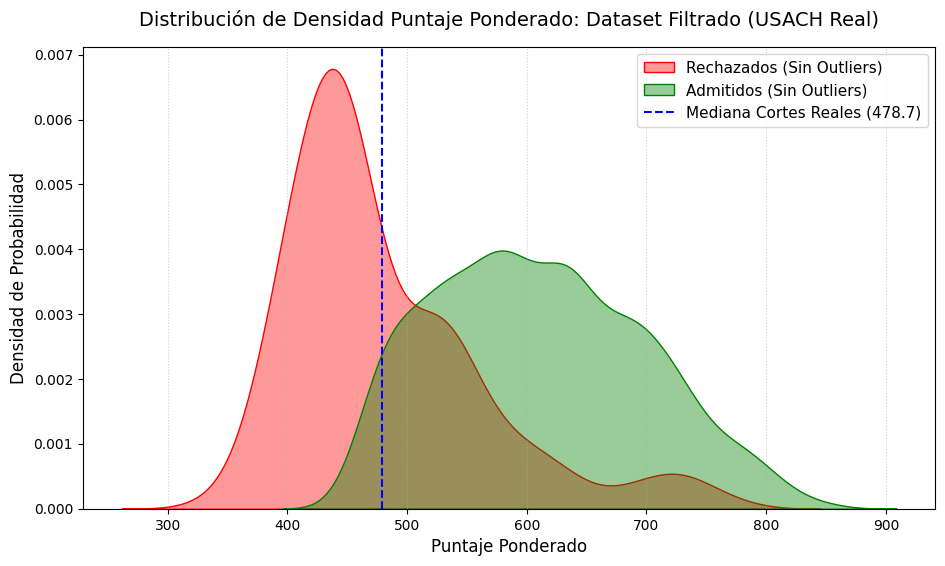

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 6))
sns.kdeplot(data=df_nuevo[df_nuevo['admit'] == 0], x='puntaje_ponderado', label='Rechazados (Sin Outliers)', fill=True, color='red', alpha=0.4)

sns.kdeplot(data=df_nuevo[df_nuevo['admit'] == 1], x='puntaje_ponderado', label='Admitidos (Sin Outliers)', fill=True, color='green', alpha=0.4)

# 4. Estética y etiquetas del gráfico
plt.title('Distribución de Densidad Puntaje Ponderado: Dataset Filtrado (USACH Real)', fontsize=14, pad=15)
plt.xlabel('Puntaje Ponderado', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)

plt.axvline(x=df_nuevo['puntaje_corte'].median(), color='blue', linestyle='--', label=f"Mediana Cortes Reales ({df_nuevo['puntaje_corte'].median():.1f})")

plt.legend(fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# 5. Desplegar gráfico
plt.show()

/tmp/ipykernel_2142/8721819.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_nuevo, x='admit', palette=['#ff4d4d', '#33cc33'])


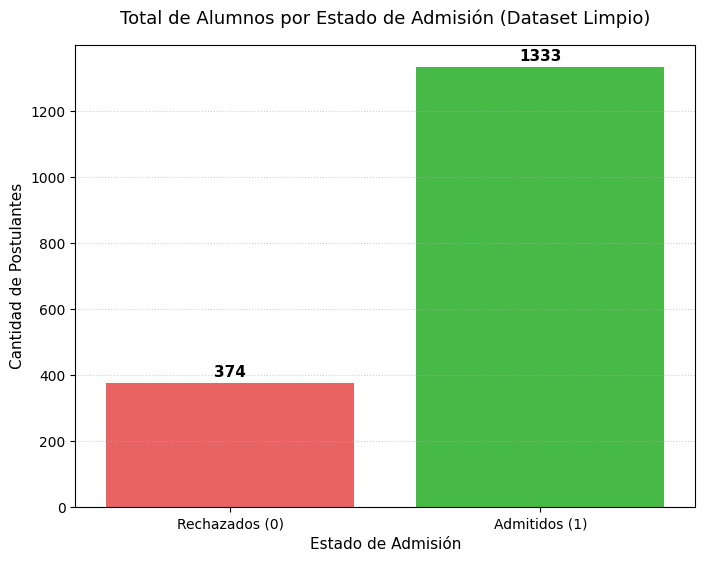

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño del lienzo
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_nuevo, x='admit', palette=['#ff4d4d', '#33cc33'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Total de Alumnos por Estado de Admisión (Dataset Limpio)', fontsize=13, pad=15)
plt.xlabel('Estado de Admisión', fontsize=11)
plt.ylabel('Cantidad de Postulantes', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Rechazados (0)', 'Admitidos (1)'])
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 5. Desplegar gráfico
plt.show()

Despues de ver este grafico para que el modelo no se overfitee tenemos que aumentar la población minoritaria.

## Aumento de la poblacion minoritaria

Usaremos la tecnica SMOTENC que consiste en generar registros del grupo minoritario donde creamos mediante código nuevos registros de alumnos admitidos inventando puntajes PAES altos (ej. entre 700 y 900 puntos) y asignándoles carreras de la USACH de manera que su brecha sea positiva.

Tambien usamos SMOTENC para respetar las variables categoricas en lugar de interpolarlas y tener puntajes bajos, nem bajo y un rank alto tambien copiamos el valor de vecinos cercanos

In [44]:
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTENC
import pandas as pd
import numpy as np

variables_numericas = ['puntaje_ponderado', 'nem', 'rank', 'puntaje_corte']
X_num = df_nuevo[variables_numericas]
y_num = df_nuevo['admit']

# rank está en el índice 2 dentro de variables_numericas
# ['puntaje_ponderado', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje']
#         0               1      2           3                 4
smote = SMOTENC(
    categorical_features=[2],  # rank es categórico (1, 2, 3, 4)
    random_state=42,
    k_neighbors=3
  # SMOTENC identifica sus k vecinos más cercanos dentro de la misma clase. Estos vecinos se utilizan como base para crear nuevas muestras.
)
X_resampled, y_resampled = smote.fit_resample(X_num, y_num)

df_balanceado = pd.DataFrame(X_resampled, columns=variables_numericas)
df_balanceado['admit'] = y_resampled


In [45]:
# Redondear variables continuas (rank ya viene como entero correcto desde SMOTENC)
df_balanceado['puntaje_ponderado'] = df_balanceado['puntaje_ponderado'].round().astype(int)
df_balanceado['rank']              = df_balanceado['rank'].round().astype(int)
df_balanceado['nem']               = df_balanceado['nem'].round(2)
df_balanceado['brecha_puntaje'] = df_balanceado['puntaje_ponderado'] - df_balanceado['puntaje_corte']

In [46]:
# ── Filtro de seguridad post-SMOTENC
# Por si quedara algún residuo imposible: rank=1 con NEM muy bajo no existe
# en la realidad educativa chilena (cuartil superior del colegio = NEM alto).
antes = len(df_balanceado)
df_balanceado = df_balanceado[
    ~((df_balanceado['rank'] == 1) & (df_balanceado['nem'] < 5.5))
].copy()
df_balanceado = df_balanceado[
    ~((df_balanceado['rank'] == 2) & (df_balanceado['nem'] < 4.8))
].copy()
despues = len(df_balanceado)

In [47]:
print("=== BALANCEO CON SMOTENC COMPLETADO ===")
print(f"Registros antes de SMOTENC  : {len(df_nuevo)}")
print(f"Registros después de SMOTENC: {despues}")
print(f"Muestras imposibles filtradas: {antes - despues}")
print("\nNueva distribución de clases:")
print(df_balanceado['admit'].value_counts())

=== BALANCEO CON SMOTENC COMPLETADO ===
Registros antes de SMOTENC  : 1707
Registros después de SMOTENC: 2638
Muestras imposibles filtradas: 28

Nueva distribución de clases:
admit
0    1329
1    1309
Name: count, dtype: int64


In [48]:
print("\n=== VERIFICACIÓN: rank nunca debería ser 1 con NEM < 5.5 ===")
problema = df_balanceado[(df_balanceado['rank'] == 1) & (df_balanceado['nem'] < 5.5)]
print(f"Combinaciones imposibles restantes: {len(problema)}  (debe ser 0)")


=== VERIFICACIÓN: rank nunca debería ser 1 con NEM < 5.5 ===
Combinaciones imposibles restantes: 0  (debe ser 0)


In [49]:
print("\n=== RANGO REAL DE CADA VARIABLE TRAS SMOTENC ===")
print(df_balanceado[['puntaje_ponderado', 'nem', 'rank', 'puntaje_corte']].describe().round(2))


=== RANGO REAL DE CADA VARIABLE TRAS SMOTENC ===
       puntaje_ponderado      nem     rank  puntaje_corte
count            2638.00  2638.00  2638.00        2638.00
mean              545.65     5.72     3.14         517.23
std               108.11     0.51     0.98          75.88
min               337.00     4.60     1.00         457.50
25%               454.00     5.31     2.00         462.45
50%               532.00     5.70     3.00         478.70
75%               626.00     6.10     4.00         555.65
max               847.00     6.80     4.00         775.30


In [50]:
print("=== Outliers de SMOTE: Admitidos con NEM bajo y Ranking alto ===")
outliers_smote = df_balanceado[
    (df_balanceado['admit'] == 1) &
    (df_balanceado['nem'] < 5.0) &
    ((df_balanceado['rank'] == 2) | (df_balanceado['rank'] == 2))
]

if not outliers_smote.empty:
    print(f"Se encontraron {len(outliers_smote)} estudiantes que cumplen estas condiciones:")
    display(outliers_smote)
else:
    print("No se encontraron estudiantes que cumplan con las condiciones de NEM muy bajo y ranking 1 o 2 y que fueran admitidos en el dataset balanceado.")


=== Outliers de SMOTE: Admitidos con NEM bajo y Ranking alto ===
Se encontraron 3 estudiantes que cumplen estas condiciones:


,puntaje_ponderado,nem,rank,puntaje_corte,admit,brecha_puntaje
637,463,4.8,2,457.50,1,5.50
1020,482,4.8,2,457.50,1,24.50
1210,524,4.9,2,462.45,1,61.55


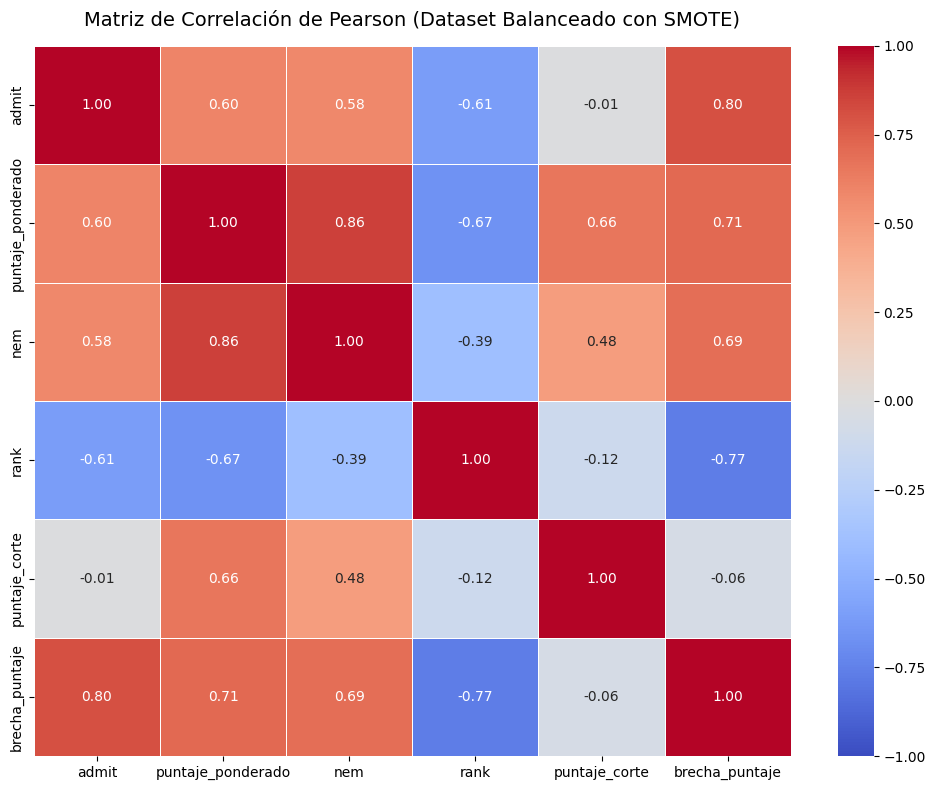

In [51]:
plt.figure(figsize=(10, 8))
corr_matrix = df_balanceado[['admit', 'puntaje_ponderado', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje']].corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            vmin=-1,
            vmax=1)
plt.title('Matriz de Correlación de Pearson (Dataset Balanceado con SMOTE)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Creacion del SET de pruebas

Usaremos el 80% para que el modelo se entrene y el 20% del dataset como validacion o prueba

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Import StandardScaler

variables_predictoras = ['puntaje_ponderado', 'nem', 'rank', 'puntaje_corte']

X = df_balanceado[variables_predictoras]
y = df_balanceado['admit']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Aplicar StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== DIVISIÓN Y ESCALADO DE DATOS COMPLETADO ===")
print(f"Conjunto de ENTRENAMIENTO (X_train_scaled): {X_train_scaled.shape[0]} alumnos (70%)")
print(f"Conjunto de PRUEBA (X_test_scaled):         {X_test_scaled.shape[0]} alumnos (30%)")
print("-" * 50)
print("Distribución de clases en el set de prueba (y_test):")
print(y_test.value_counts())

=== DIVISIÓN Y ESCALADO DE DATOS COMPLETADO ===
Conjunto de ENTRENAMIENTO (X_train_scaled): 1846 alumnos (70%)
Conjunto de PRUEBA (X_test_scaled):         792 alumnos (30%)
--------------------------------------------------
Distribución de clases en el set de prueba (y_test):
admit
0    399
1    393
Name: count, dtype: int64


### Primer arbol

Haremos un arbol de decision con las variables que tenemos sin utilizar ninguna tecnica para evitar el overfitting, no usaremos profundidades, ni tampoco usaremos un muestreo

In [53]:
arbol_inicial = DecisionTreeClassifier(criterion='entropy', random_state=42)

print("Entrenando el Árbol de Decisión Inicial...")
arbol_inicial.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

Entrenando el Árbol de Decisión Inicial...
¡Modelo entrenado con éxito!


In [54]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = arbol_inicial.predict(X_test)

# 2. Calcular y desplegar el Accuracy (Exactitud)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo (Accuracy): {accuracy * 100:.2f}%\n")


Exactitud del modelo (Accuracy): 98.86%



In [55]:
# 3. Mostrar el reporte detallado de clasificación
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred, target_names=['Rechazados (0)', 'Admitidos (1)']))

=== REPORTE DE CLASIFICACIÓN ===
                precision    recall  f1-score   support

Rechazados (0)       0.99      0.99      0.99       399
 Admitidos (1)       0.99      0.99      0.99       393

      accuracy                           0.99       792
     macro avg       0.99      0.99      0.99       792
  weighted avg       0.99      0.99      0.99       792



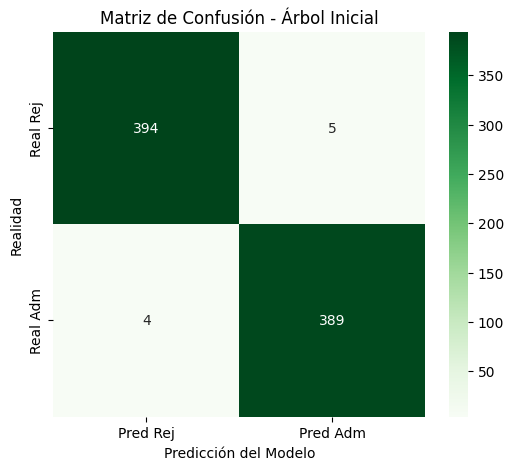

In [56]:
# 4. Graficar la Matriz de Confusión para ver dónde se confunde exactamente
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred Rej', 'Pred Adm'], yticklabels=['Real Rej', 'Real Adm'])
plt.title('Matriz de Confusión - Árbol Inicial')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

Por que tan buenas metricas?

Esto ocurre porque, al usar datos sintéticos de SMOTEMC combinados con la brecha matemática exacta, el árbol crece de forma ilimitada hasta memorizar cada fila del dataset. (Es un caso de overfitting)

Tambien es debido a que el arbol utilizo una profundidad que no fue seleccionada ni evaluada esto permite que el arbol sea muy profundo y a la vez muy generalista al tomar sus decisiones

Acciones a realizar

Pre-procesamiento Crítico: Eliminaremos la variable delatora (brecha_puntaje) del entrenamiento para obligar al árbol a aprender de las variables reales del alumno (paes, nem, rank).

Poda (Pruning): Limitaremos el crecimiento fijando una profundidad máxima (max_depth) y un mínimo de muestras por hoja (min_samples_leaf).

### Segundo entrenamiento Regresion Logistica

Este modelo esta basado en la funcion sigmoide que es una ecuacion para encontrar una curva, es ideal para predecir variables binarias a partir de datos continuos como en este caso sera la paes, nem y rank

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Definir las variables puras del perfil del alumno
variables_perfil_puro = ['puntaje_ponderado', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje']
X_puro = df_balanceado[variables_perfil_puro]
y_puro = df_balanceado['admit']

# 2. Inicializar el escalador y transformar los datos de entrada
scaler_perfil = StandardScaler()
X_escalado = scaler_perfil.fit_transform(X_puro)

# 3. Volver a hacer la división 80/20 pero usando los datos ESCALADOS
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_escalado,
    y_puro,
    test_size=0.20,
    random_state=42,
    stratify=y_puro
)

print("=== PRE-PROCESAMIENTO: ESCALAMIENTO COMPLETADO ===")
print(f"Datos escalados correctamente. Forma de X_train_p: {X_train_p.shape}")

=== PRE-PROCESAMIENTO: ESCALAMIENTO COMPLETADO ===
Datos escalados correctamente. Forma de X_train_p: (2110, 5)


Le dimos todas las variables ya que la mayoria son continuas esto nos permite que el modelo sea mas robusto y encuentre la relacion que hay los puntajes corte y los de la paes

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

modelo_logistico = LogisticRegression(class_weight='balanced', random_state=42) #max_iter = 100 por defecto pero se puede cambiar
modelo_logistico.fit(X_train_p, y_train_p)

# Realizar predicciones
y_pred_logistico = modelo_logistico.predict(X_test_p)

Este algoritmo Dibuja una línea continua (que puede ser diagonal) usando una fórmula matemática. Es ideal para modelar relaciones numéricas y proporciones tambien calcula probabilidades fluidas, permitiendo extrapolar valores muy altos o muy bajos con total coherencia. Esto es debido que las variables continuas toman mas peso en el entrenamiento

In [59]:
# Calcular y mostrar las métricas de evaluación
print("\n=== EVALUACIÓN DE RENDIMIENTO DEL MODELO DE REGRESIÓN LOGÍSTICA ===")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test_p, y_pred_logistico) * 100:.2f}%")

print("\n=== REPORTE DE CLASIFICACIÓN DETALLADO ===")
print(classification_report(y_test_p, y_pred_logistico, target_names=['Rechazados (0)', 'Admitidos (1)']))



=== EVALUACIÓN DE RENDIMIENTO DEL MODELO DE REGRESIÓN LOGÍSTICA ===
Exactitud Global (Accuracy): 98.48%

=== REPORTE DE CLASIFICACIÓN DETALLADO ===
                precision    recall  f1-score   support

Rechazados (0)       0.97      1.00      0.99       266
 Admitidos (1)       1.00      0.97      0.98       262

      accuracy                           0.98       528
     macro avg       0.99      0.98      0.98       528
  weighted avg       0.99      0.98      0.98       528



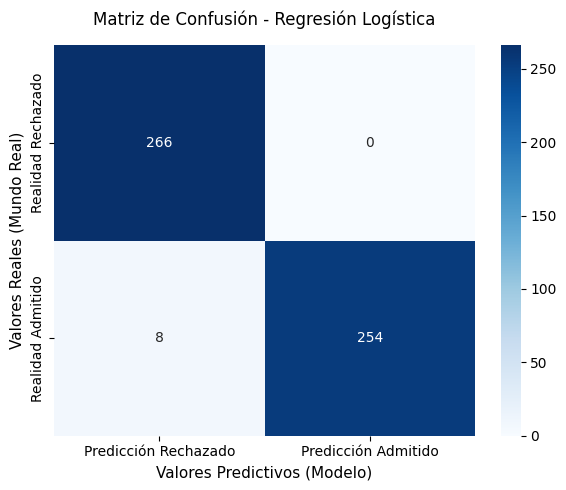

In [60]:
# Graficar la Matriz de Confusión
matriz_confusion_logistico = confusion_matrix(y_test_p, y_pred_logistico)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusion_logistico,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicción Rechazado', 'Predicción Admitido'],
            yticklabels=['Realidad Rechazado', 'Realidad Admitido'])
plt.title('Matriz de Confusión - Regresión Logística',
          fontsize=12, pad=15)
plt.ylabel('Valores Reales (Mundo Real)', fontsize=11)
plt.xlabel('Valores Predictivos (Modelo)', fontsize=11)
plt.tight_layout()
plt.show()

Como aqui la prediccion se hace en base a una ecuacion matematica no deberia por que estar overfiteado y saberse los datos de memoria debido que en el conjunto de pruebas se equivoco 12 veces dando verdadero negativo

## Poda

Pre-poda (Restricción anticipada): Limita los hiperparámetros antes del entrenamiento, como max_depth (profundidad máxima), min_samples_split (muestras mínimas para dividir un nodo) o min_samples_leaf (muestras mínimas requeridas en una hoja).


Post-poda: Permite que el árbol crezca al máximo y luego recorta las ramas que aportan poco valor predictivo, generalmente utilizando el parámetro de complejidad de costos (ccp_alpha)

In [61]:
# 1. Crear el modelo aplicando Pre-poda (Restricciones de crecimiento)
arbol_podado = DecisionTreeClassifier(
    criterion='entropy', #métrica para medir la pureza de los datos
    max_depth=6, #Profundidad del modelo
    min_samples_leaf=20, #Exige que cualquier nodo final (hoja) tenga como mínimo 10 muestras de datos para poder existir
    class_weight='balanced', #hace que el árbol penalice más los errores en la clase minoritaria, corrigiendo el sesgo del SMOTE
    random_state=42
)

# 2. Entrenar el modelo utilizando los conjuntos de datos escalados
print("Entrenando el Árbol de Decisión Podado con datos escalados...")
arbol_podado.fit(X_train, y_train)

print("¡Modelo entrenado con éxito controlando el sobreajuste y la escala!")

Entrenando el Árbol de Decisión Podado con datos escalados...
¡Modelo entrenado con éxito controlando el sobreajuste y la escala!


In [62]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_p = arbol_podado.predict(X_test)

accuracy_final = accuracy_score(y_test, y_pred)
print("=== EVALUACIÓN DE RENDIMIENTO DEL MODELO ===")
print(f"Exactitud Global (Accuracy): {accuracy_final * 100:.2f}%\n")

# 3. Desplegar el reporte detallado con las métricas exigidas por la rúbrica
print("=== REPORTE DE CLASIFICACIÓN DETALLADO ===")
print(classification_report(y_test, y_pred, target_names=['Rechazados (0)', 'Admitidos (1)']))

=== EVALUACIÓN DE RENDIMIENTO DEL MODELO ===
Exactitud Global (Accuracy): 98.86%

=== REPORTE DE CLASIFICACIÓN DETALLADO ===
                precision    recall  f1-score   support

Rechazados (0)       0.99      0.99      0.99       399
 Admitidos (1)       0.99      0.99      0.99       393

      accuracy                           0.99       792
     macro avg       0.99      0.99      0.99       792
  weighted avg       0.99      0.99      0.99       792



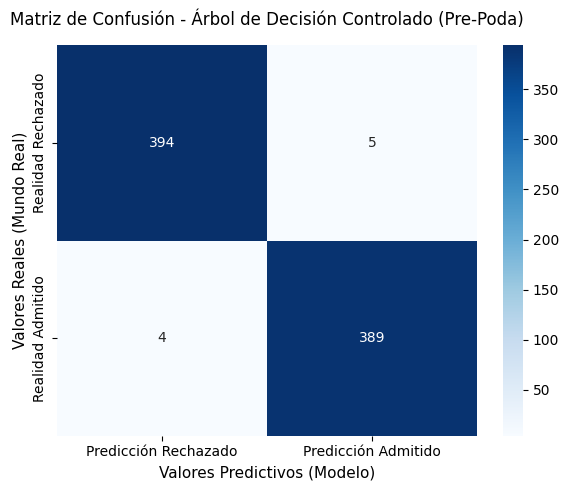

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calcular la matriz de confusión con los datos reales vs. predicciones
matriz_confusion = confusion_matrix(y_test, y_pred)

# 2. Configurar el tamaño del gráfico
plt.figure(figsize=(6, 5))

# 3. Dibujar el mapa de calor (Heatmap) con las anotaciones correspondientes
sns.heatmap(matriz_confusion,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicción Rechazado', 'Predicción Admitido'],
            yticklabels=['Realidad Rechazado', 'Realidad Admitido'])

# 4. Detalles estéticos del gráfico para el informe
plt.title('Matriz de Confusión - Árbol de Decisión Controlado (Pre-Poda)', fontsize=12, pad=15)
plt.ylabel('Valores Reales (Mundo Real)', fontsize=11)
plt.xlabel('Valores Predictivos (Modelo)', fontsize=11)
plt.tight_layout()

# 5. Desplegar el gráfico
plt.show()

Tenemos muy buenas metricas pero el arbol de decision es muy determinista en caso de valores atipicos no funcionara muy bien ya que funciona con reglas muy especificas donde no puede extrapolar valores externos (Debido a que la brecha de puntaje es la respuesta para el arbol de decision no se agrego debido al obvio overfitting que causaria)

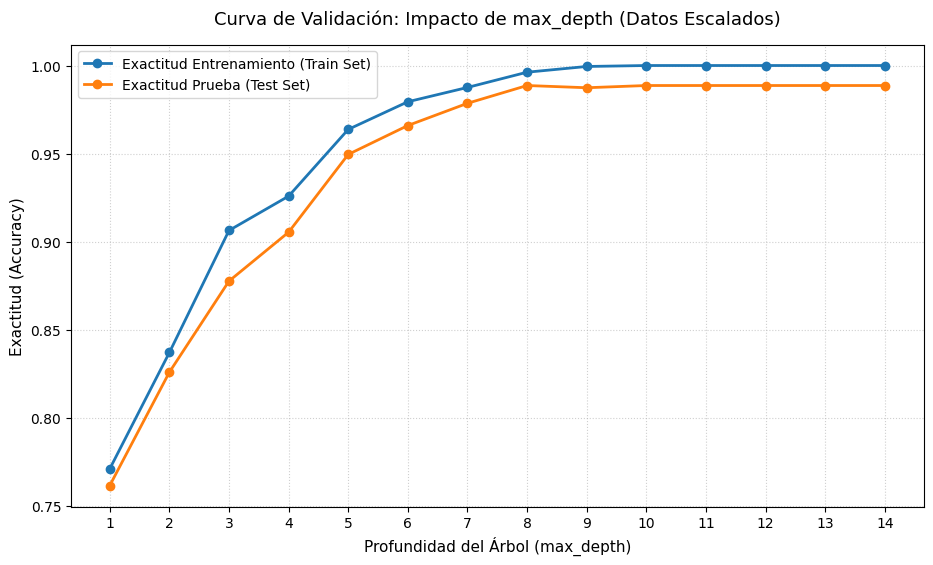

In [64]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

train_scores_e = []
test_scores_e = []
profundidades_e = range(1, 15)

for depth in profundidades_e:
    modelo_depth = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    modelo_depth.fit(X_train, y_train) # Tus datos de entrenamiento actuales


    train_scores_e.append(accuracy_score(y_train, modelo_depth.predict(X_train)))
    test_scores_e.append(accuracy_score(y_test, modelo_depth.predict(X_test)))

# 3. Graficar la curva de sobreajuste
plt.figure(figsize=(11, 6))
plt.plot(profundidades_e, train_scores_e, label='Exactitud Entrenamiento (Train Set)', marker='o', color='#1f77b4', linewidth=2)
plt.plot(profundidades_e, test_scores_e, label='Exactitud Prueba (Test Set)', marker='o', color='#ff7f0e', linewidth=2)

plt.title('Curva de Validación: Impacto de max_depth (Datos Escalados)', fontsize=13, pad=15)
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=11)
plt.ylabel('Exactitud (Accuracy)', fontsize=11)
plt.xticks(profundidades_e)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Random forest

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

modelo_random_forest = RandomForestClassifier(
    criterion='entropy',
    max_depth=6,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_estimators=100 # Número de árboles en el bosque
)

# 2. Entrenar el modelo con los datos escalados (X_train_p, y_train_p)
print("Entrenando el modelo Random Forest...")
modelo_random_forest.fit(X_train, y_train)
print("¡Modelo Random Forest entrenado con éxito!")

Entrenando el modelo Random Forest...
¡Modelo Random Forest entrenado con éxito!


In [66]:
# 3. Realizar predicciones sobre el set de prueba escalado e independiente (X_test_p)
y_pred_rf = modelo_random_forest.predict(X_test)
y_prob_rf = modelo_random_forest.predict_proba(X_test)[:, 1] # Probabilidades para la clase positiva (Admitido)

# 4. Calcular y mostrar las métricas de evaluación
print("\n=== EVALUACIÓN DE RENDIMIENTO DEL MODELO RANDOM FOREST ===")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\n=== REPORTE DE CLASIFICACIÓN DETALLADO ===")
print(classification_report(y_test, y_pred_rf, target_names=['Rechazados (0)', 'Admitidos (1)']))


=== EVALUACIÓN DE RENDIMIENTO DEL MODELO RANDOM FOREST ===
Exactitud Global (Accuracy): 96.97%
ROC-AUC: 0.9965

=== REPORTE DE CLASIFICACIÓN DETALLADO ===
                precision    recall  f1-score   support

Rechazados (0)       0.97      0.97      0.97       399
 Admitidos (1)       0.97      0.96      0.97       393

      accuracy                           0.97       792
     macro avg       0.97      0.97      0.97       792
  weighted avg       0.97      0.97      0.97       792



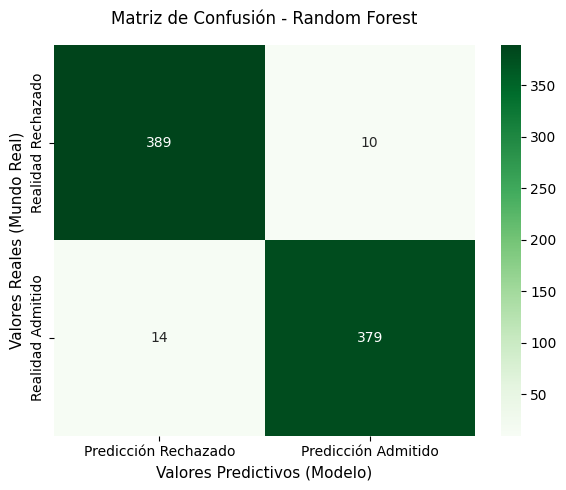

In [67]:
# 5. Graficar la Matriz de Confusión
matriz_confusion_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusion_rf,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Predicción Rechazado', 'Predicción Admitido'],
            yticklabels=['Realidad Rechazado', 'Realidad Admitido'])
plt.title('Matriz de Confusión - Random Forest',
          fontsize=12, pad=15)
plt.ylabel('Valores Reales (Mundo Real)', fontsize=11)
plt.xlabel('Valores Predictivos (Modelo)', fontsize=11)
plt.tight_layout()
plt.show()


Random forest tuvo muy buenos resultados pero a la hora de colocar alumnos con puntajes atipicos como 1000 puntos este modelo decae debido a que no hay formula matematica que generalice la admision de un alumno.

Para carreras con cortes muy altos, la inmensa mayoría de las muestras de entrenamiento históricas son rechazadas (ya que muy pocos postulantes superan la valla).

## K-Means

K-Means es un algoritmo de aprendizaje no supervisado. A diferencia del árbol que predice si un alumno entra o no (admit), K-Means no busca etiquetas; busca patrones ocultos en los datos para agrupar a los estudiantes por similitud geométrica (distancia euclidiana)

En el contexto del proceso de admisión, no nos interesa agruparlos solo por "admitidos" o "rechazados", sino descubrir perfiles académicos. Al entregarle al algoritmo las variables escaladas (paes, nem, rank, puntaje_corte), K-Means agrupará a los estudiantes en perfiles lógicos como:

Cluster A (Perfil de Alto Rendimiento): Alumnos con NEM y PAES muy altos, apuntando a carreras de máxima exigencia.

Cluster B (Perfil de Esfuerzo / Técnico): Alumnos con NEM/Rank muy alto pero PAES moderada, que logran entrar a carreras intermedias gracias a su rendimiento escolar.

Cluster C (Perfil Rezagado / En Riesgo): Alumnos con puntajes y notas por debajo de la media, que quedan fuera o entran muy justos a las carreras de menor corte.

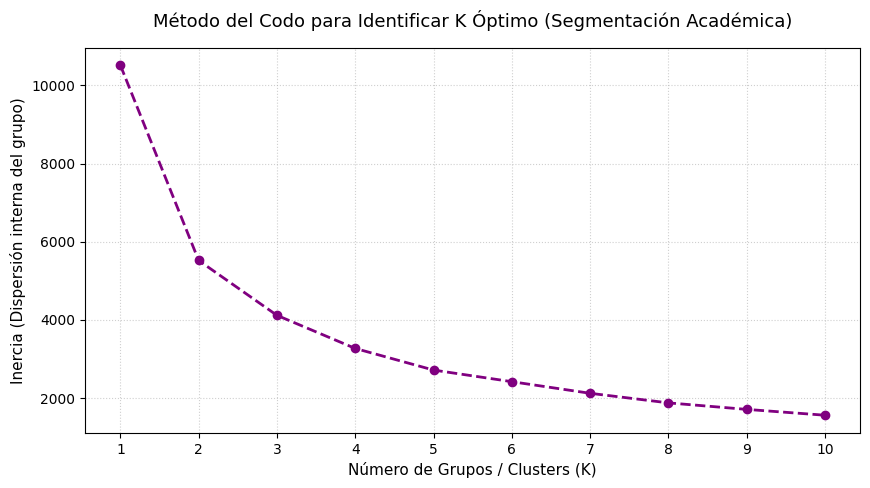

In [68]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Probar un rango de clusters (por ejemplo de 1 a 10) para calcular la inercia
inercia = []
rangos_k = range(1, 11)

for k in rangos_k:
    # n_init=10 ejecuta el algoritmo con 10 centroides iniciales distintos para asegurar el mejor óptimo local
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_train_p)
    inercia.append(kmeans_test.inertia_)

# 2. Graficar el Método del Codo
plt.figure(figsize=(10, 5))
plt.plot(rangos_k, inercia, marker='o', linestyle='--', color='purple', linewidth=2)
plt.title('Método del Codo para Identificar K Óptimo (Segmentación Académica)', fontsize=13, pad=15)
plt.xlabel('Número de Grupos / Clusters (K)', fontsize=11)
plt.ylabel('Inercia (Dispersión interna del grupo)', fontsize=11)
plt.xticks(rangos_k)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Usamos los mismos datos escalados que teniamos de antes

Centroide: es el punto central que representa el centro geométrico de un grupo de datos

In [69]:
# 1. Inicializar el modelo K-Means con el número óptimo del codo
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# 2. Entrenar el modelo y predecir los clusters directamente en el set de entrenamiento
clusters_train = kmeans_final.fit_predict(X_train_p)

print(f"¡Modelo K-Means entrenado exitosamente con K={k_optimo}!")
print("Distribución de alumnos por cluster en el set de entrenamiento:")
import numpy as np
unique, counts = np.unique(clusters_train, return_counts=True)
print(dict(zip(unique, counts)))

¡Modelo K-Means entrenado exitosamente con K=3!
Distribución de alumnos por cluster en el set de entrenamiento:
{np.int32(0): np.int64(1209), np.int32(1): np.int64(528), np.int32(2): np.int64(373)}


In [70]:
# 1. Crear un DataFrame temporal de entrenamiento para mapear los perfiles reales
# Recuperamos los índices originales para emparejar con los datos sin escalar
indices_train = y_train_p.index
df_analisis_clusters = df_balanceado.loc[indices_train].copy()

# 2. Inyectar la columna del cluster asignado
df_analisis_clusters['cluster_perfil'] = clusters_train

# 3. Calcular el promedio de las notas y puntajes reales para cada cluster
print("=== CARACTERIZACIÓN ESTADÍSTICA DE LOS PERFILES (PROMEDIOS) ===")
columnas_perfil = ['puntaje_ponderado', 'nem', 'rank', 'puntaje_corte', 'admit']
perfiles_resumen = df_analisis_clusters.groupby('cluster_perfil')[columnas_perfil].mean()

# Cambiar el formato para que se lea limpio como reporte de negocio
print(perfiles_resumen.round(2))

=== CARACTERIZACIÓN ESTADÍSTICA DE LOS PERFILES (PROMEDIOS) ===
                puntaje_ponderado   nem  rank  puntaje_corte  admit
cluster_perfil                                                     
0                          468.28  5.40  3.71         489.85   0.23
1                          623.62  6.06  2.09         488.92   1.00
2                          685.09  6.30  2.82         646.00   0.65


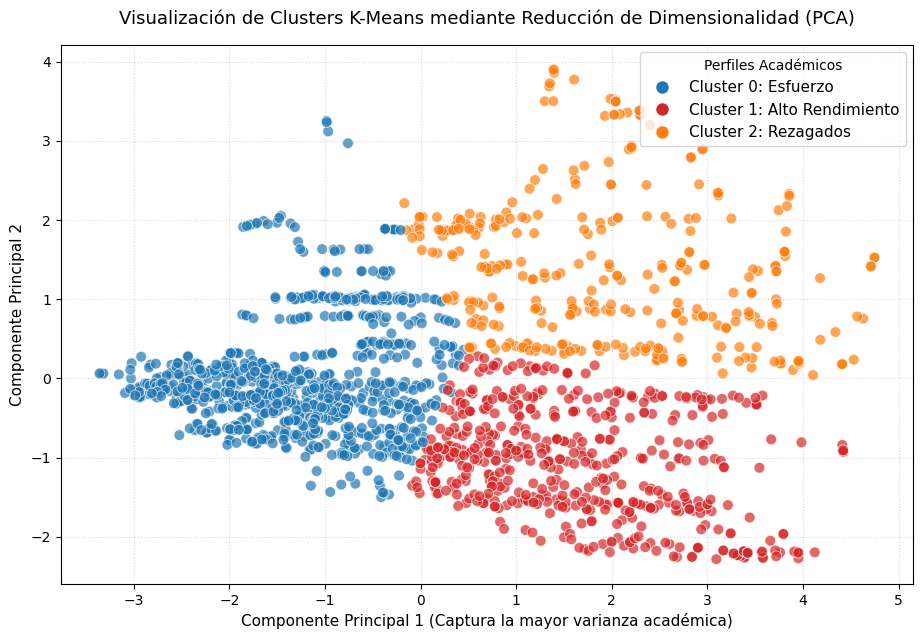

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Inicializar PCA para reducir tus 4 variables escaladas a solo 2 componentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_p) # Usamos los datos escalados de entrenamiento

# 2. Crear un DataFrame con las coordenadas de PCA y los clusters
df_pca = pd.DataFrame(X_pca, columns=['Componente Principal 1 (PC1)', 'Componente Principal 2 (PC2)'])
df_pca['cluster_perfil'] = clusters_train

# 3. Graficar la proyección PCA
plt.figure(figsize=(11, 7))
colores_perfiles = {0: '#1f77b4', 1: '#d62728', 2: '#ff7f0e'}

sns.scatterplot(
    data=df_pca,
    x='Componente Principal 1 (PC1)',
    y='Componente Principal 2 (PC2)',
    hue='cluster_perfil',
    palette=colores_perfiles,
    alpha=0.7,
    s=60,
    edgecolor='w'
)

# 4. Estética profesional
plt.title('Visualización de Clusters K-Means mediante Reducción de Dimensionalidad (PCA)', fontsize=13, pad=15)
plt.xlabel('Componente Principal 1 (Captura la mayor varianza académica)', fontsize=11)
plt.ylabel('Componente Principal 2', fontsize=11)

lineas_leyenda = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=10, label='Cluster 0: Esfuerzo'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=10, label='Cluster 1: Alto Rendimiento'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=10, label='Cluster 2: Rezagados')
]
plt.legend(handles=lineas_leyenda, title='Perfiles Académicos', fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

PCA (Análisis de Componentes Principales).

PCA es un algoritmo que toma tus 4 variables escaladas, extrae la varianza matemática máxima de todas ellas y las reduce a 2 "Súper-Variables" (Componentes Principales: PC1 y PC2) que retienen la mayor información posible sin deformar las distancias.

## Despliegue

In [74]:
import pandas as pd

# 1. Crear una copia de los datos del set de entrenamiento analizado
df_exportar = df_analisis_clusters.copy()

# 2. Buscar la columna con el nombre de la carrera en df_cortes_real
columnas_texto = df_cortes_real.select_dtypes(include=['object', 'string']).columns.tolist()

if len(columnas_texto) > 0:
    columna_nombre_carrera = columnas_texto[0]
    mapa_carreras = df_cortes_real[['puntaje_corte', columna_nombre_carrera]].drop_duplicates().set_index('puntaje_corte')[columna_nombre_carrera].to_dict()
    df_exportar['carrera'] = df_exportar['puntaje_corte'].map(mapa_carreras)
    print(f"¡Éxito! Nombres de carreras mapeados correctamente.")
else:
    df_exportar['carrera'] = "Sin Registro"
    print("No se encontró columna de texto, se asigna 'Sin Registro'.")

# 3. Inyectar las predicciones del árbol
df_exportar['prediccion_arbol_admit'] = arbol_podado.predict(df_exportar[variables_predictoras])

# 4. Guardar copia local de seguridad
df_exportar.to_csv('resultado_modelos_admision_final.csv', index=False)

¡Éxito! Nombres de carreras mapeados correctamente.


In [75]:
from google.colab import auth
import gspread
from google.auth import default
import numpy as np
import pandas as pd

# 1. Autenticar la sesión con Google
auth.authenticate_user()
credenciales, _ = default()
gc = gspread.authorize(credenciales)

# 2. Forzar la creación de un nuevo archivo V2 para evitar conflictos con el borrado
nombre_nuevo_archivo = 'Dashboard_Mineria_Datos_V2'

print(f"Creando un archivo nuevo en tu Google Drive llamado: {nombre_nuevo_archivo}...")
sh = gc.create(nombre_nuevo_archivo)
hoja = sh.get_worksheet(0)

# 3. Sanitización estricta anti-NaN antes de convertir a formato lista
df_sheets = df_exportar.reset_index(drop=True)
df_sheets.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df_sheets.columns:
    if df_sheets[col].dtype == 'object' or df_sheets[col].dtype == 'string':
        df_sheets[col] = df_sheets[col].fillna("Sin Registro")
    else:
        df_sheets[col] = df_sheets[col].fillna(0)

# 4. Transformar el DataFrame sanitizado a lista pura
datos_lista = [df_sheets.columns.values.tolist()] + df_sheets.values.tolist()

# 5. Escribir los datos en la nueva hoja limpia
hoja.clear()
hoja.update(range_name='A1', values=datos_lista)

print(f"¡Listo! Archivo creado y sincronizado con éxito.")
print(f"Búscalo en tu Google Drive o conéctalo en Looker Studio como: '{nombre_nuevo_archivo}'")

Creando un archivo nuevo en tu Google Drive llamado: Dashboard_Mineria_Datos_V2...
¡Listo! Archivo creado y sincronizado con éxito.
Búscalo en tu Google Drive o conéctalo en Looker Studio como: 'Dashboard_Mineria_Datos_V2'


### Creacion PKL

dashboards looker: https://datastudio.google.com/reporting/8c2055ba-4bca-48a9-9c9f-091f555d7e26

In [76]:
import pickle

# Guardar el modelo de árbol de decisión (arbol_podado)
with open('modelo_arbol.pkl', 'wb') as f:
    pickle.dump(arbol_podado, f)

# Guardar el modelo Random Forest (modelo_random_forest)
with open('modelo_random_forest.pkl', 'wb') as f:
    pickle.dump(modelo_random_forest, f)

# Guardar el modelo K-Means (kmeans_final)
with open('modelo_kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

#Guardar el modelo de regresion logistica
with open('modelo_logistico.pkl', 'wb') as f:
    pickle.dump(modelo_logistico, f)

Para este despliegue nos quedaremos con Random forest debido a que el arbol de decision sufrio un Underfitting debido a que generalizo la variable ranking donde si esta es menor o = a 2.5 este era admitido automaticamente dejando de lado la decision acerca de la brecha de puntaje por eso teniamos tantos falsos positivos.

Random forest Al promediar la opinión de 100 árboles diferentes (técnica de Bagging), suaviza las fronteras de decisión y reduce drásticamente la varianza. No está sobreajustado; de hecho, generaliza mucho mejor y corrige varios errores marginales (por ejemplo, el caso problemático de NEM 4.0, Rank 2 y PAES 500 ahora es clasificado correctamente como NO).

In [77]:
print("para main.py:\n")
print(f"PUNTAJE_PONDERADO_MEAN, PUNTAJE_PONDERADO_STD = {df_balanceado['puntaje_ponderado'].mean():.6f}, {df_balanceado['puntaje_ponderado'].std():.6f}")
print(f"NEM_MEAN, NEM_STD = {df_balanceado['nem'].mean():.6f}, {df_balanceado['nem'].std():.6f}")
print(f"RANK_MEAN, RANK_STD = {df_balanceado['rank'].mean():.6f}, {df_balanceado['rank'].std():.6f}")
print(f"CORTE_MEAN, CORTE_STD = {df_balanceado['puntaje_corte'].mean():.6f}, {df_balanceado['puntaje_corte'].std():.6f}")

para main.py:

PUNTAJE_PONDERADO_MEAN, PUNTAJE_PONDERADO_STD = 545.652767, 108.111805
NEM_MEAN, NEM_STD = 5.723161, 0.513429
RANK_MEAN, RANK_STD = 3.143290, 0.984875
CORTE_MEAN, CORTE_STD = 517.226914, 75.883747
